In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Checking if grapic card available as pytorch need specific delacation to use CPU of GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [2]:
df = pd.read_csv("../../data/raw/riceClassification.csv")
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [3]:
# Doing the preprocessing
df.dropna(inplace=True)
df.drop('id',axis=1, inplace=True)

In [4]:
# Checking the class 
print(df['Class'].unique())
print(df['Class'].value_counts())

#data is not hugly imbalance hence 

[1 0]
Class
1    9985
0    8200
Name: count, dtype: int64


In [5]:
# Normalise the data to have better performance.
# Deviding the colomn value with the maximum of that colomn, the scale will update but the value ratio will remain constant

original_df = df.copy()   # keeping a copy of orginal df to check final result

for col in df.columns:
    df[col] = df[col]/df[col].abs().max()

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [6]:
# Spliting Data

X = np.array(df.iloc[:,:-1])
y = np.array(df['Class'])

# Trainging and testing data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [7]:
# We are spliting the test data for validation set
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5)

In [8]:
#checking the shape of X data
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [9]:
# We are modifing the model to match our dataset to use 

class dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype = torch.float32).to(device)    # .to(device) saying what resource is using, CPU or GPU
        self.y = torch.tensor(y, dtype = torch.float32).to(device)

    # get the length of dataset
    def __len__(self):
        return len(self.X)

    #getitem will get specific item with index
    def __getitem__(self,index):
        return self.X[index], self.y[index]

training_data = dataset(X_train, y_train)
validation_data = dataset(X_val,y_val)
testing_data = dataset(X_test,y_test)

In [10]:
# Dataloader (Creating batches for trainging validating and testing data)

train_dataloader = DataLoader(training_data, batch_size=8,shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=8,shuffle=True)
testing_dataloader = DataLoader(testing_data, batch_size=8,shuffle=True)


In [11]:
#checking the sample output, geting only the first loop
for x, y in train_dataloader:
    print(x)
    print("==========")
    print(y)
    break

tensor([[0.6551, 0.7465, 0.7633, 0.9181, 0.6216, 0.8094, 0.6536, 0.6469, 0.8586,
         0.5549],
        [0.4072, 0.5841, 0.6259, 0.9058, 0.3919, 0.6382, 0.7755, 0.5227, 0.8176,
         0.5295],
        [0.8903, 0.8731, 0.8798, 0.9216, 0.8365, 0.9436, 0.8946, 0.7410, 0.8892,
         0.5630],
        [0.7835, 0.8262, 0.8284, 0.9228, 0.7451, 0.8852, 0.6645, 0.7092, 0.8544,
         0.5658],
        [0.6211, 0.8582, 0.6409, 0.9741, 0.5931, 0.7881, 0.6622, 0.6892, 0.7170,
         0.7597],
        [0.6403, 0.7137, 0.7917, 0.8959, 0.6186, 0.8002, 0.8534, 0.6413, 0.8537,
         0.5114],
        [0.4559, 0.6936, 0.5767, 0.9590, 0.4368, 0.6752, 0.7489, 0.5708, 0.7676,
         0.6823],
        [0.7796, 0.8272, 0.8209, 0.9252, 0.7449, 0.8830, 0.9254, 0.7332, 0.7954,
         0.5717]])
tensor([0., 1., 0., 0., 1., 0., 1., 0.])


In [12]:
# Building our Model

hidden_layer = 10

class my_model(nn.Module):
    def __init__(self):
        super(my_model, self).__init__()      #inheriting the constructor of nn.Module module

        #Creat the layer
        self.input_layer = nn.Linear(X.shape[1], hidden_layer)   #in_features input colomns X.shape[1], out_features, hidden neuron
        self.hidden_layer = nn.Linear(hidden_layer, hidden_layer)
        self.output_layer = nn.Linear(hidden_layer, 1)
        self.sigmoid = nn.Sigmoid() 

    #definig the forward movent of data
    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layer(x)
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

model = my_model().to(device)

In [13]:
#Summary
summary(model, (X.shape[1], ))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                   [-1, 10]             110
            Linear-3                    [-1, 1]              11
           Sigmoid-4                    [-1, 1]               0
Total params: 231
Trainable params: 231
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [14]:
#Loss Function
criterion = nn.BCELoss()   #binary cross entropy loss initilasing the loss
optimizer = Adam(model.parameters(), lr= 1e-3)

In [15]:
# Training Function

# 1. Creating empty list, to get loss data for each epoch, to plot and see over fitting

total_loss_train_plot = []
total_loss_valication_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

# 2. for loop to get the loss value. 
# reshape change the array shape while squeez compress the dimension to required value

epochs = 10
for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for data in train_dataloader:     #training_dataloader is getting data from training dataset
        inputs, labels = data
        
        #Forward Propogation
        prediction = model(inputs).squeeze(1)  # squeeze to match the dimention of labels
        batch_loss = criterion(prediction, labels)  #valication
        total_loss_train += batch_loss.item()
        
        acc = ((prediction).round() == labels).sum().item()
        total_acc_train += acc

        #Backward Propogation
        batch_loss.backward()        # torch have to be asked to to start backward
        optimizer.step()             # tells how many steps to go back
        optimizer.zero_grad(set_to_none=True)   #reset the gradient to calculate for backward pass
    
    # Inferance/ Valication
    with torch.no_grad():          
        for data in validation_dataloader:    # for inputs, labels in validation_dataloader: these both are same way of writing
            inputs, labels = data
            
            prediction = model(inputs).squeeze(1)
            batch_loss = criterion(prediction, labels) 
            total_loss_val += batch_loss.item()
            
            acc = ((prediction.round() == labels)).sum().item()
            total_acc_val += acc
            
    # Getting out of nested loop and updating the empty list and plotting
    
    # Before appending we can just roundoff and normalise the data to esier calculation
    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_loss_valication_plot.append(round(total_loss_val/1000,4))

    # As accuracy is ratio, so we can normalise it also by deviding it by len of data
    total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100,4)) #getting percentage
    total_acc_validation_plot.append(round(total_acc_val/training_data.__len__() * 100,4)) 

    # Optional part, we can print the accuracy and training of each epoch
    print(f''' Epoch no: {epoch+1} Training Loss: {round(total_loss_train/1000,4)} Train Accuracy: {round(total_acc_train/training_data.__len__() * 100,4)}
                Validation Loss: {round(total_loss_val/1000,4)} Valication Accuracy: {round(total_acc_val/training_data.__len__() * 100,4)} 
            ''')
    print("="*25)


 Epoch no: 1 Training Loss: 0.338 Train Accuracy: 92.5132
                Validation Loss: 0.0187 Valication Accuracy: 21.0857 
            
 Epoch no: 2 Training Loss: 0.077 Train Accuracy: 98.4524
                Validation Loss: 0.0159 Valication Accuracy: 21.0857 
            
 Epoch no: 3 Training Loss: 0.0736 Train Accuracy: 98.3816
                Validation Loss: 0.015 Valication Accuracy: 21.1093 
            
 Epoch no: 4 Training Loss: 0.0723 Train Accuracy: 98.4052
                Validation Loss: 0.015 Valication Accuracy: 21.1486 
            
 Epoch no: 5 Training Loss: 0.0736 Train Accuracy: 98.4366
                Validation Loss: 0.0145 Valication Accuracy: 21.125 
            
 Epoch no: 6 Training Loss: 0.0717 Train Accuracy: 98.4209
                Validation Loss: 0.0179 Valication Accuracy: 21.015 
            
 Epoch no: 7 Training Loss: 0.071 Train Accuracy: 98.4916
                Validation Loss: 0.0153 Valication Accuracy: 21.1407 
            
 Epoch no: 8 

In [16]:
# Testing the model

with torch.no_grad():
    total_test_loss = 0
    total_test_acc = 0
    for inputs, labels in testing_dataloader:
        
        prediction = model(inputs).squeeze(1)
        
        batch_loss_test = criterion(prediction, labels).item()
        total_test_loss += batch_loss_test

        acc = ((prediction.round() == labels)).sum().item()
        total_test_acc += acc

    print("Accuracy:", round(total_test_acc/testing_data.__len__() * 100,4))

Accuracy: 98.9736


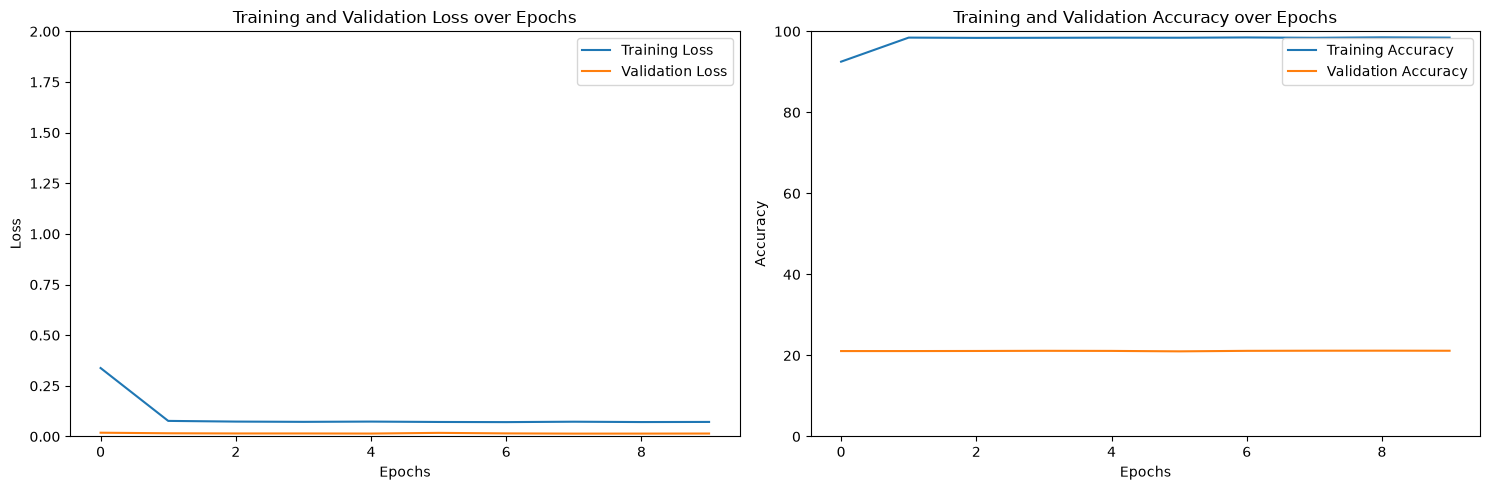

In [17]:
# Visualisation

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_valication_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()
     


In [18]:
# Inferance 

area = float(input("Area: "))/original_df['Area'].abs().max()
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("EquivDiameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("AspectRation: "))/original_df['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))

Area:  23
Major Axis Length:  3
Minor Axis Length:  5
Eccentricity:  23
Convex Area:  76
EquivDiameter:  2
Extent:  45
Perimeter:  3
Roundness:  3456
AspectRation:  3


tensor([0.], grad_fn=<SigmoidBackward0>)
Class is:  0
